# Patient-Level Aggregation

## Purpose

This notebook develops and evaluates methods for aggregating multiple tumor samples from the same patient into a single patient-level observation. Because survival analysis assumes independent observations, patients with multiple samples cannot simply be counted multiple times. Different aggregation strategies are compared to determine how tumor mutational burden (TMB) should be represented at the patient level.

## Objectives

* Quantify the number of samples contributed by each patient.
* Compare TMB values across multiple samples from the same patient.
* Evaluate several aggregation methods for TMB.
* Compare patient-level datasets generated by each method.
* Select an aggregation strategy for the final survival analysis.
* Export the finalized patient-level dataset.

# Imports

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import plotly.express as px

# Load cleaned sample data 

In [2]:
PROJECT_DIR = Path.cwd().parent

DATA_FILE = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "sample_level_cleaned.tsv"
)

df = pd.read_csv(
    DATA_FILE,
    sep="\t"
)

df.head()

,Study ID,Patient ID,Sample ID,Age at Which Sequencing was Reported (Years),Cancer Type,Cancer Type Detailed,Ethnicity Category,Fraction Genome Altered,Gene Panel,Institute Source,...,Race Category,Sample Class,Number of Samples Per Patient,Sample coverage,Sample Type,Sex,Somatic Status,TMB (nonsynonymous),Tumor Purity,Event
0,soft_tissue_msk_2023,P-0006113,P-0006113-T01-IM5,18.0,Soft Tissue Sarcoma,Alveolar Rhabdomyosarcoma,"Spanish NOS; Hispanic NOS, Latino NOS",0.0844,IMPACT410,MSKCC,...,WHITE,Tumor,2,949,Primary,Male,Matched,0.978720,80.0,1.0
1,soft_tissue_msk_2023,P-0006113,P-0006113-T02-IM6,18.0,Soft Tissue Sarcoma,Alveolar Rhabdomyosarcoma,"Spanish NOS; Hispanic NOS, Latino NOS",0.3861,IMPACT468,MSKCC,...,WHITE,Tumor,2,743,Metastasis,Male,Matched,0.864698,30.0,1.0
2,soft_tissue_msk_2023,P-0013120,P-0013120-T04-IM6,19.0,Soft Tissue Sarcoma,Embryonal Rhabdomyosarcoma,Non-Spanish; Non-Hispanic,0.1217,IMPACT468,MSKCC,...,WHITE,Tumor,2,727,Metastasis,Female,Matched,0.000000,30.0,1.0
3,soft_tissue_msk_2023,P-0013120,P-0013120-T06-IM6,20.0,Soft Tissue Sarcoma,Embryonal Rhabdomyosarcoma,Non-Spanish; Non-Hispanic,0.2839,IMPACT468,NaN,...,WHITE,Tumor,2,666,Metastasis,Female,Matched,0.000000,70.0,1.0
4,soft_tissue_msk_2023,P-0018770,P-0018770-T02-IM6,18.0,Soft Tissue Sarcoma,Embryonal Rhabdomyosarcoma,Non-Spanish; Non-Hispanic,0.6574,IMPACT468,MSKCC,...,ASIAN-FAR EAST/INDIAN SUBCONT,Tumor,2,651,Primary,Male,Matched,0.864698,70.0,1.0


# Samples per patient

In [3]:
sample_counts = (
    df.groupby("Patient ID")
      .size()
      .reset_index(name="Number of Samples")
)

sample_counts

,Patient ID,Number of Samples
0,P-0006113,2
1,P-0013120,2
2,P-0018770,2
3,P-0019531,2
4,P-0022317,2
5,P-0028971,2
6,P-0033453,2
7,P-0035844,3
8,P-0045478,2
9,P-0048073,2


# Distribution of Sample Count

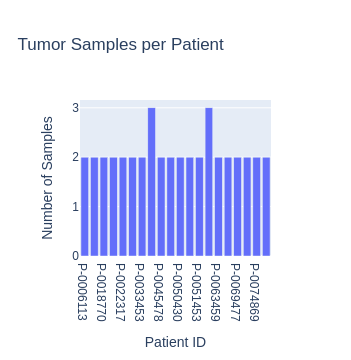

In [4]:
fig = px.bar(
    sample_counts,
    x="Patient ID",
    y="Number of Samples",
    title="Tumor Samples per Patient"
)

fig.show()

# Compare TMB within each patient

In [5]:
patient_summary = (
    df.groupby("Patient ID")
      .agg(
          Sample_Count=("Sample ID", "count"),
          Mean_TMB=("TMB (nonsynonymous)", "mean"),
          Median_TMB=("TMB (nonsynonymous)", "median"),
          Min_TMB=("TMB (nonsynonymous)", "min"),
          Max_TMB=("TMB (nonsynonymous)", "max"),
          SD_TMB=("TMB (nonsynonymous)", "std")
      )
      .reset_index()
)

patient_summary

,Patient ID,Sample_Count,Mean_TMB,Median_TMB,Min_TMB,Max_TMB,SD_TMB
0,P-0006113,2,0.921709,0.921709,0.864698,0.978720,0.080625
1,P-0013120,2,0.000000,0.000000,0.000000,0.000000,0.000000
2,P-0018770,2,1.729396,1.729396,0.864698,2.594094,1.222868
3,P-0019531,2,0.432349,0.432349,0.000000,0.864698,0.611434
4,P-0022317,2,0.000000,0.000000,0.000000,0.000000,0.000000
5,P-0028971,2,1.297047,1.297047,0.864698,1.729396,0.611434
6,P-0033453,2,2.937742,2.937742,2.594094,3.281389,0.485991
7,P-0035844,3,1.928927,2.461042,0.864698,2.461042,0.921649
8,P-0045478,2,0.000000,0.000000,0.000000,0.000000,0.000000
9,P-0048073,2,1.685045,1.685045,1.640694,1.729396,0.062722


# Calculate TMB range

In [6]:
patient_summary["Range_TMB"] = (
    patient_summary["Max_TMB"]
    - patient_summary["Min_TMB"]
)

patient_summary.sort_values(
    "Range_TMB",
    ascending=False
)

,Patient ID,Sample_Count,Mean_TMB,Median_TMB,Min_TMB,Max_TMB,SD_TMB,Range_TMB
11,P-0051132,2,2.461042,2.461042,0.000000,4.922083,3.480439,4.922083
16,P-0069477,2,1.230521,1.230521,0.000000,2.461042,1.740219,2.461042
2,P-0018770,2,1.729396,1.729396,0.864698,2.594094,1.222868,1.729396
10,P-0050430,2,1.662870,1.662870,0.864698,2.461042,1.128785,1.596344
7,P-0035844,3,1.928927,2.461042,0.864698,2.461042,0.921649,1.596344
5,P-0028971,2,1.297047,1.297047,0.864698,1.729396,0.611434,0.864698
3,P-0019531,2,0.432349,0.432349,0.000000,0.864698,0.611434,0.864698
14,P-0063459,2,0.410174,0.410174,0.000000,0.820347,0.580073,0.820347
18,P-0074869,2,5.332257,5.332257,4.922083,5.742431,0.580073,0.820347
13,P-0060318,3,1.367245,1.640694,0.820347,1.640694,0.473628,0.820347


# Visualize within-patient variability

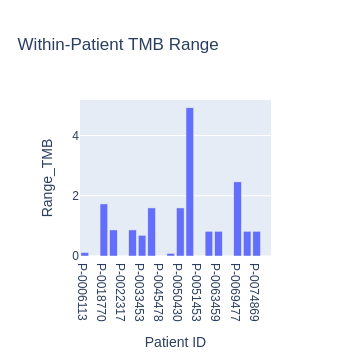

In [7]:
fig = px.bar(

    patient_summary,

    x="Patient ID",

    y="Range_TMB",

    hover_data=[
        "Mean_TMB",
        "Median_TMB",
        "Min_TMB",
        "Max_TMB"
    ],

    title="Within-Patient TMB Range"

)

fig.show()

# Compare Aggregation Methods

In [8]:
# Mean 
patient_mean = (
    df.groupby("Patient ID", as_index=False)
      .agg({
          "TMB (nonsynonymous)": "mean",
          "Overall Survival (Months)": "first",
          "Overall Survival Status": "first"
      })
)

patient_mean.head()

,Patient ID,TMB (nonsynonymous),Overall Survival (Months),Overall Survival Status
0,P-0006113,0.921709,37.085,1:DECEASED
1,P-0013120,0.000000,31.890,1:DECEASED
2,P-0018770,1.729396,32.449,1:DECEASED
3,P-0019531,0.432349,69.008,0:LIVING
4,P-0022317,0.000000,5.688,1:DECEASED


In [9]:
# Median 
patient_median = (
    df.groupby("Patient ID", as_index=False)
      .agg({
          "TMB (nonsynonymous)": "median",
          "Overall Survival (Months)": "first",
          "Overall Survival Status": "first"
      })
)

In [10]:
# Maximum 
patient_max = (
    df.groupby("Patient ID", as_index=False)
      .agg({
          "TMB (nonsynonymous)": "max",
          "Overall Survival (Months)": "first",
          "Overall Survival Status": "first"
      })
)

In [11]:
# Minimum
patient_min = (
    df.groupby("Patient ID", as_index=False)
      .agg({
          "TMB (nonsynonymous)": "min",
          "Overall Survival (Months)": "first",
          "Overall Survival Status": "first"
      })
)

# Compare methods side-by-side

In [12]:
comparison = patient_summary[[
    "Patient ID",
    "Mean_TMB",
    "Median_TMB",
    "Min_TMB",
    "Max_TMB"
]]

comparison

,Patient ID,Mean_TMB,Median_TMB,Min_TMB,Max_TMB
0,P-0006113,0.921709,0.921709,0.864698,0.978720
1,P-0013120,0.000000,0.000000,0.000000,0.000000
2,P-0018770,1.729396,1.729396,0.864698,2.594094
3,P-0019531,0.432349,0.432349,0.000000,0.864698
4,P-0022317,0.000000,0.000000,0.000000,0.000000
5,P-0028971,1.297047,1.297047,0.864698,1.729396
6,P-0033453,2.937742,2.937742,2.594094,3.281389
7,P-0035844,1.928927,2.461042,0.864698,2.461042
8,P-0045478,0.000000,0.000000,0.000000,0.000000
9,P-0048073,1.685045,1.685045,1.640694,1.729396


# Scatter Comparison

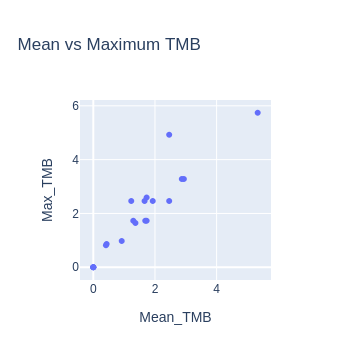

In [13]:
fig = px.scatter(

    comparison,

    x="Mean_TMB",

    y="Max_TMB",

    hover_name="Patient ID",

    title="Mean vs Maximum TMB"

)

fig.show()
# Repeat for other combinations if desired

# Are survival variables constant 

Quality control

In [14]:
consistency = (
    df.groupby("Patient ID")
      .agg(
          Survival_Time_Values=(
              "Overall Survival (Months)",
              lambda x: x.nunique()
          ),
          Survival_Status_Values=(
              "Overall Survival Status",
              lambda x: x.nunique()
          )
      )
)

consistency

,Survival_Time_Values,Survival_Status_Values
Patient ID,,
P-0006113,1,1
P-0013120,1,1
P-0018770,1,1
P-0019531,1,1
P-0022317,1,1
P-0028971,0,0
P-0033453,1,1
P-0035844,1,1
P-0045478,1,1


# Identify Inconsistent Patterns

In [15]:
consistency[
    (consistency["Survival_Time_Values"] > 1)
    |
    (consistency["Survival_Status_Values"] > 1)
]

,Survival_Time_Values,Survival_Status_Values
Patient ID,,


# Choose the default aggregation

In [16]:
patient_df = patient_mean.copy()

patient_df.head()

,Patient ID,TMB (nonsynonymous),Overall Survival (Months),Overall Survival Status
0,P-0006113,0.921709,37.085,1:DECEASED
1,P-0013120,0.000000,31.890,1:DECEASED
2,P-0018770,1.729396,32.449,1:DECEASED
3,P-0019531,0.432349,69.008,0:LIVING
4,P-0022317,0.000000,5.688,1:DECEASED


# Export

In [17]:
OUTPUT_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
)

patient_df.to_csv(

    OUTPUT_DIR / "patient_level_mean.tsv",

    sep="\t",

    index=False

)

# Conclusions


• 20 unique patients contributed 42 tumor samples.

• Most patients contributed two samples, while a small number contributed three.

• Tumor mutational burden varies substantially among samples from the same patient.

• Mean, median, minimum, and maximum aggregation methods produce different patient-level TMB estimates.

• Survival information should be identical across samples from the same patient.

• A patient-level dataset is required for statistically valid Kaplan–Meier survival analysis because each patient must contribute only one independent observation.